In [1]:
import sys
sys.path.append('../src')

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time

#noinspection PyUnresolvedReferences
from model import UNet
#noinspection PyUnresolvedReferences
from dataset import get_dataloader

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")

Устройство: cpu


In [3]:
class Discriminator(nn.Module):
    """
    Отличает реальные цвета от сгенерированных
    Вход: цветное изображение 3×128×128
    Выход: вероятность (0 = фейк, 1 = реальное)
    """
    def __init__(self, in_channels=3):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 1, kernel_size=4, stride=1, padding=0),
            nn.AdaptiveAvgPool2d(1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1, 1)

In [4]:
criterion_gan = nn.BCELoss()  # Binary Cross Entropy (для дискриминатора)

def adversarial_loss(predictions, targets):
    """
    predictions: что предсказал дискриминатор
    targets: чего мы хотим (1 = реальное, 0 = фейк)
    """
    return criterion_gan(predictions, targets)

In [5]:
def run_experiment(config, experiment_id, save_examples=True):
    """
    config: словарь с параметрами
    experiment_id: номер эксперимента
    save_examples: сохранить ли примеры после 5 эпох
    """

    print(f"\n{'='*60}")
    print(f"Эксперимент {experiment_id}")
    print(f"Параметры:")
    for key, value in config.items():
        print(f"  {key}: {value}")
    print('='*60)

    # Распаковка параметров
    lr_G = config['lr_G']
    lr_D = config['lr_D']
    lambda_mse = config['lambda_mse']
    lambda_gan = config['lambda_gan']
    d_train_freq = config['d_train_freq']
    num_epochs = config.get('num_epochs', 5)  # по умолчанию 5 эпох

    # Загрузка данных
    data_dir = '../data/processed/test'
    train_loader = get_dataloader(data_dir, batch_size=4, shuffle=True)

    # Создание моделей
    generator = UNet(in_channels=1, out_channels=3).to(device)
    discriminator = Discriminator(in_channels=3).to(device)

    # Оптимизаторы
    optimizer_G = optim.Adam(generator.parameters(), lr=lr_G, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=lr_D, betas=(0.5, 0.999))

    # Потери
    criterion_mse = nn.MSELoss()

    # Для логирования
    losses_G = []
    losses_D = []
    losses_mse = []

    start_time = time.time()

    for epoch in range(num_epochs):
        epoch_G = 0
        epoch_D = 0
        epoch_mse = 0
        n_batches = 0

        for batch_idx, (gray_batch, color_batch) in enumerate(train_loader):
            real_batch = color_batch.to(device)
            gray_batch = gray_batch.to(device)
            batch_size = real_batch.size(0)

            # Label smoothing
            real_labels = torch.ones(batch_size, 1).to(device) * 0.9
            fake_labels = torch.zeros(batch_size, 1).to(device) + 0.1

            # Шум
            noise = torch.randn_like(gray_batch) * 0.05
            gray_batch_noisy = gray_batch + noise

            # ===== DISCRIMINATOR =====
            loss_D = 0
            if batch_idx % d_train_freq == 0:
                optimizer_D.zero_grad()

                # Реальные
                real_output = discriminator(real_batch)
                loss_real = adversarial_loss(real_output, real_labels)

                # Фейковые
                with torch.no_grad():
                    fake_batch = generator(gray_batch_noisy)
                fake_output = discriminator(fake_batch)
                loss_fake = adversarial_loss(fake_output, fake_labels)

                loss_D = (loss_real + loss_fake) / 2
                loss_D.backward()
                optimizer_D.step()

            # ===== GENERATOR =====
            optimizer_G.zero_grad()

            fake_batch = generator(gray_batch_noisy)

            # Adversarial loss
            fake_output = discriminator(fake_batch)
            loss_G_adv = adversarial_loss(fake_output, real_labels)

            # MSE loss
            loss_G_mse = criterion_mse(fake_batch, real_batch)

            # Total loss
            loss_G = lambda_mse * loss_G_mse + lambda_gan * loss_G_adv
            loss_G.backward()
            optimizer_G.step()

            # Логирование
            epoch_G += loss_G.item()
            epoch_D += loss_D
            epoch_mse += loss_G_mse.item()
            n_batches += 1

            # Печать прогресса
            if (batch_idx + 1) % 50 == 0:
                print(f"[{experiment_id}] Эпоха {epoch+1}/{num_epochs} | Батч {batch_idx+1} | G: {loss_G.item():.4f} | D: {loss_D:.4f}")

        # Сохраняем средние за эпоху
        losses_G.append(epoch_G / n_batches)
        losses_D.append(epoch_D / n_batches)
        losses_mse.append(epoch_mse / n_batches)

        print(f"[{experiment_id}] ✅ Эпоха {epoch+1} | G: {losses_G[-1]:.4f} | D: {losses_D[-1]:.4f} | MSE: {losses_mse[-1]:.4f}")

    # Визуализация результатов
    generator.eval()
    examples = None

    if save_examples:
        gray_batch, color_batch = next(iter(train_loader))
        with torch.no_grad():
            gray_batch = gray_batch.to(device)
            fake_batch = generator(gray_batch)

            # Сохраняем примеры для сравнения
            examples = {
                'gray': gray_batch[0].cpu().squeeze().numpy(),
                'fake': fake_batch[0].cpu().permute(1, 2, 0).numpy(),
                'real': color_batch[0].cpu().permute(1, 2, 0).numpy()
            }
            # Нормализация
            examples['fake'] = (examples['fake'] + 1) / 2
            examples['fake'] = np.clip(examples['fake'], 0, 1)

    # Сохранение модели (для лучшего эксперимента)
    if experiment_id == 1:  # только для первого пока не знаем лучший
        torch.save(generator.state_dict(), f'models/grid_search_exp_{experiment_id}.pth')

    elapsed_time = time.time() - start_time
    print(f"[{experiment_id}] Завершён за {elapsed_time/60:.1f} минут")

    return {
        'config': config,
        'losses_G': losses_G,
        'losses_D': losses_D,
        'losses_mse': losses_mse,
        'examples': examples,
        'time': elapsed_time
    }


In [6]:
def plot_comparison(results):
    """Сравнивает графики потерь всех экспериментов"""
    import math

    # Определяем количество подграфиков
    n_results = len(results)
    n_cols = min(3, n_results)  # максимум 3 колонки
    n_rows = math.ceil(n_results / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

    # Если только один подграфик, делаем axes списком
    if n_results == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx, res in enumerate(results):
        ax = axes[idx]

        # Гарантированная конвертация тензоров в числа
        losses_G = []
        losses_D = []

        for loss in res['losses_G']:
            if torch.is_tensor(loss):
                losses_G.append(loss.detach().cpu().item())  # .item() = число
            else:
                losses_G.append(loss)

        for loss in res['losses_D']:
            if torch.is_tensor(loss):
                losses_D.append(loss.detach().cpu().item())
            else:
                losses_D.append(loss)

        epochs = range(1, len(losses_G) + 1)

        ax.plot(epochs, losses_G, 'b-', label='Generator', linewidth=2)
        ax.plot(epochs, losses_D, 'r-', label='Discriminator', linewidth=2)
        ax.set_title(f"Exp {idx+1}", fontsize=12, fontweight='bold')
        ax.set_xlabel('Эпоха')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)

        # Добавляем параметры в подзаголовок
        params = f"lr_G={res['config']['lr_G']:.0e}\nlr_D={res['config']['lr_D']:.0e}\nλ_MSE={res['config']['lambda_mse']}\nλ_GAN={res['config']['lambda_gan']}"
        ax.text(0.05, 0.95, params, transform=ax.transAxes, fontsize=8,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Скрываем пустые подграфики
    for idx in range(len(results), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig('grid_search_results/comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

def show_examples(results):
    """Показывает примеры предсказаний для каждого эксперимента"""
    fig, axes = plt.subplots(len(results), 3, figsize=(12, 3 * len(results)))

    # Если только один эксперимент, делаем axes двумерным
    if len(results) == 1:
        axes = axes.reshape(1, -1)

    for idx, res in enumerate(results):
        if res['examples'] is None:
            continue

        # Конвертируем и нормализуем входное (ч/б)
        gray_img = res['examples']['gray']
        if torch.is_tensor(gray_img):
            gray_img = gray_img.detach().cpu().numpy()
        if gray_img.ndim == 3 and gray_img.shape[0] == 1:
            gray_img = gray_img.squeeze(0)  # убираем канал
        axes[idx, 0].imshow(gray_img, cmap='gray')
        axes[idx, 0].set_title(f"Exp {idx+1}: Вход (ч/б)")
        axes[idx, 0].axis('off')

        # Конвертируем и нормализуем предсказание
        fake_img = res['examples']['fake']
        if torch.is_tensor(fake_img):
            fake_img = fake_img.detach().cpu().numpy()
        # Меняем порядок каналов (C,H,W) → (H,W,C)
        if fake_img.ndim == 3 and fake_img.shape[0] == 3:
            fake_img = fake_img.transpose(1, 2, 0)
        # Нормализация из [-1,1] в [0,1] если нужно
        if fake_img.min() < 0:
            fake_img = (fake_img + 1) / 2
        fake_img = np.clip(fake_img, 0, 1)
        axes[idx, 1].imshow(fake_img)
        axes[idx, 1].set_title(f"Exp {idx+1}: Предсказание")
        axes[idx, 1].axis('off')

        # Конвертируем реальное
        real_img = res['examples']['real']
        if torch.is_tensor(real_img):
            real_img = real_img.detach().cpu().numpy()
        if real_img.ndim == 3 and real_img.shape[0] == 3:
            real_img = real_img.transpose(1, 2, 0)
        axes[idx, 2].imshow(real_img)
        axes[idx, 2].set_title("Реальное цветное")
        axes[idx, 2].axis('off')

    plt.tight_layout()
    plt.savefig('grid_search_results/examples.png', dpi=150, bbox_inches='tight')
    plt.show()

In [7]:
configs = [
    # Эксперимент 1: базовая конфигурация
    {
        'lr_G': 2e-4,
        'lr_D': 2e-4,
        'lambda_mse': 10,
        'lambda_gan': 1,
        'd_train_freq': 1,
        'num_epochs': 5
    },
    # Эксперимент 2: D учится реже
    {
        'lr_G': 2e-4,
        'lr_D': 2e-4,
        'lambda_mse': 10,
        'lambda_gan': 1,
        'd_train_freq': 2,
        'num_epochs': 5
    },
    # Эксперимент 3: меньше lr_D, меньше lr_G
    {
        'lr_G': 1e-4,
        'lr_D': 1e-4,
        'lambda_mse': 10,
        'lambda_gan': 0.5,
        'd_train_freq': 2,
        'num_epochs': 5
    },
    # Эксперимент 4: классическая GAN настройка
    {
        'lr_G': 2e-4,
        'lr_D': 1e-4,
        'lambda_mse': 5,
        'lambda_gan': 0.5,
        'd_train_freq': 2,
        'num_epochs': 5
    },
    # Эксперимент 5: сильный акцент на GAN
    {
        'lr_G': 1e-4,
        'lr_D': 5e-5,
        'lambda_mse': 5,
        'lambda_gan': 1,
        'd_train_freq': 3,
        'num_epochs': 5
    },
    # Эксперимент 6: низкий lr_D, высокий lr_G
    {
        'lr_G': 3e-4,
        'lr_D': 1e-4,
        'lambda_mse': 5,
        'lambda_gan': 0.2,
        'd_train_freq': 3,
        'num_epochs': 5
    },
]

In [8]:
results = []

# Создаём папку для сохранения примеров
Path('grid_search_results').mkdir(exist_ok=True)

for i, config in enumerate(configs):
    print(f"\n\n{'#'*60}")
    print(f"Запуск эксперимента {i+1}/{len(configs)}")
    print('#'*60)

    result = run_experiment(config, experiment_id=i+1, save_examples=True)
    results.append(result)

    # Сохраняем промежуточные результаты
    torch.save(results, 'grid_search_results/all_results.pth')

    # Небольшая пауза между экспериментами для очистки памяти
    torch.cuda.empty_cache()

print("\n" + "="*60)
print("✅ Все эксперименты завершены!")
print("="*60)



############################################################
Запуск эксперимента 1/6
############################################################

Эксперимент 1
Параметры:
  lr_G: 0.0002
  lr_D: 0.0002
  lambda_mse: 10
  lambda_gan: 1
  d_train_freq: 1
  num_epochs: 5
[1] ✅ Эпоха 1 | G: 4.4900 | D: 0.6970 | MSE: 0.3793
[1] ✅ Эпоха 2 | G: 3.8044 | D: 0.6761 | MSE: 0.3095
[1] ✅ Эпоха 3 | G: 3.4696 | D: 0.6674 | MSE: 0.2748
[1] ✅ Эпоха 4 | G: 3.2340 | D: 0.6549 | MSE: 0.2489
[1] ✅ Эпоха 5 | G: 2.9987 | D: 0.6449 | MSE: 0.2236
[1] Завершён за 0.8 минут


############################################################
Запуск эксперимента 2/6
############################################################

Эксперимент 2
Параметры:
  lr_G: 0.0002
  lr_D: 0.0002
  lambda_mse: 10
  lambda_gan: 1
  d_train_freq: 2
  num_epochs: 5
[2] ✅ Эпоха 1 | G: 4.6724 | D: 0.6916 | MSE: 0.3915
[2] ✅ Эпоха 2 | G: 3.9750 | D: 0.6673 | MSE: 0.3243
[2] ✅ Эпоха 3 | G: 3.5641 | D: 0.6646 | MSE: 0.2846
[2] ✅ Эпоха 4 | 

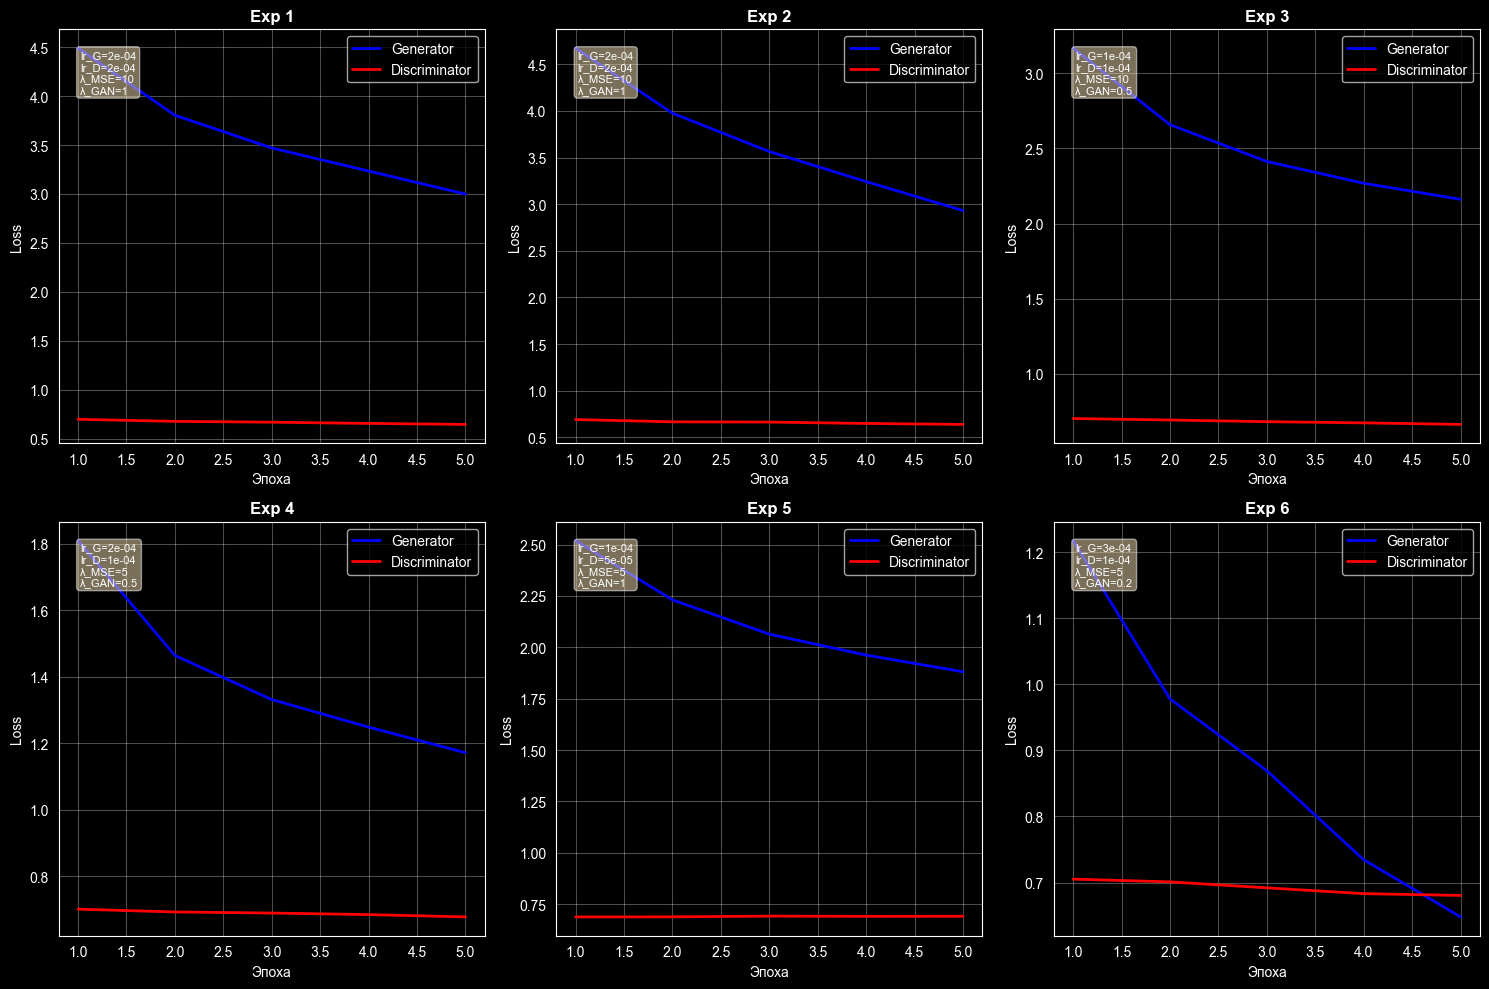

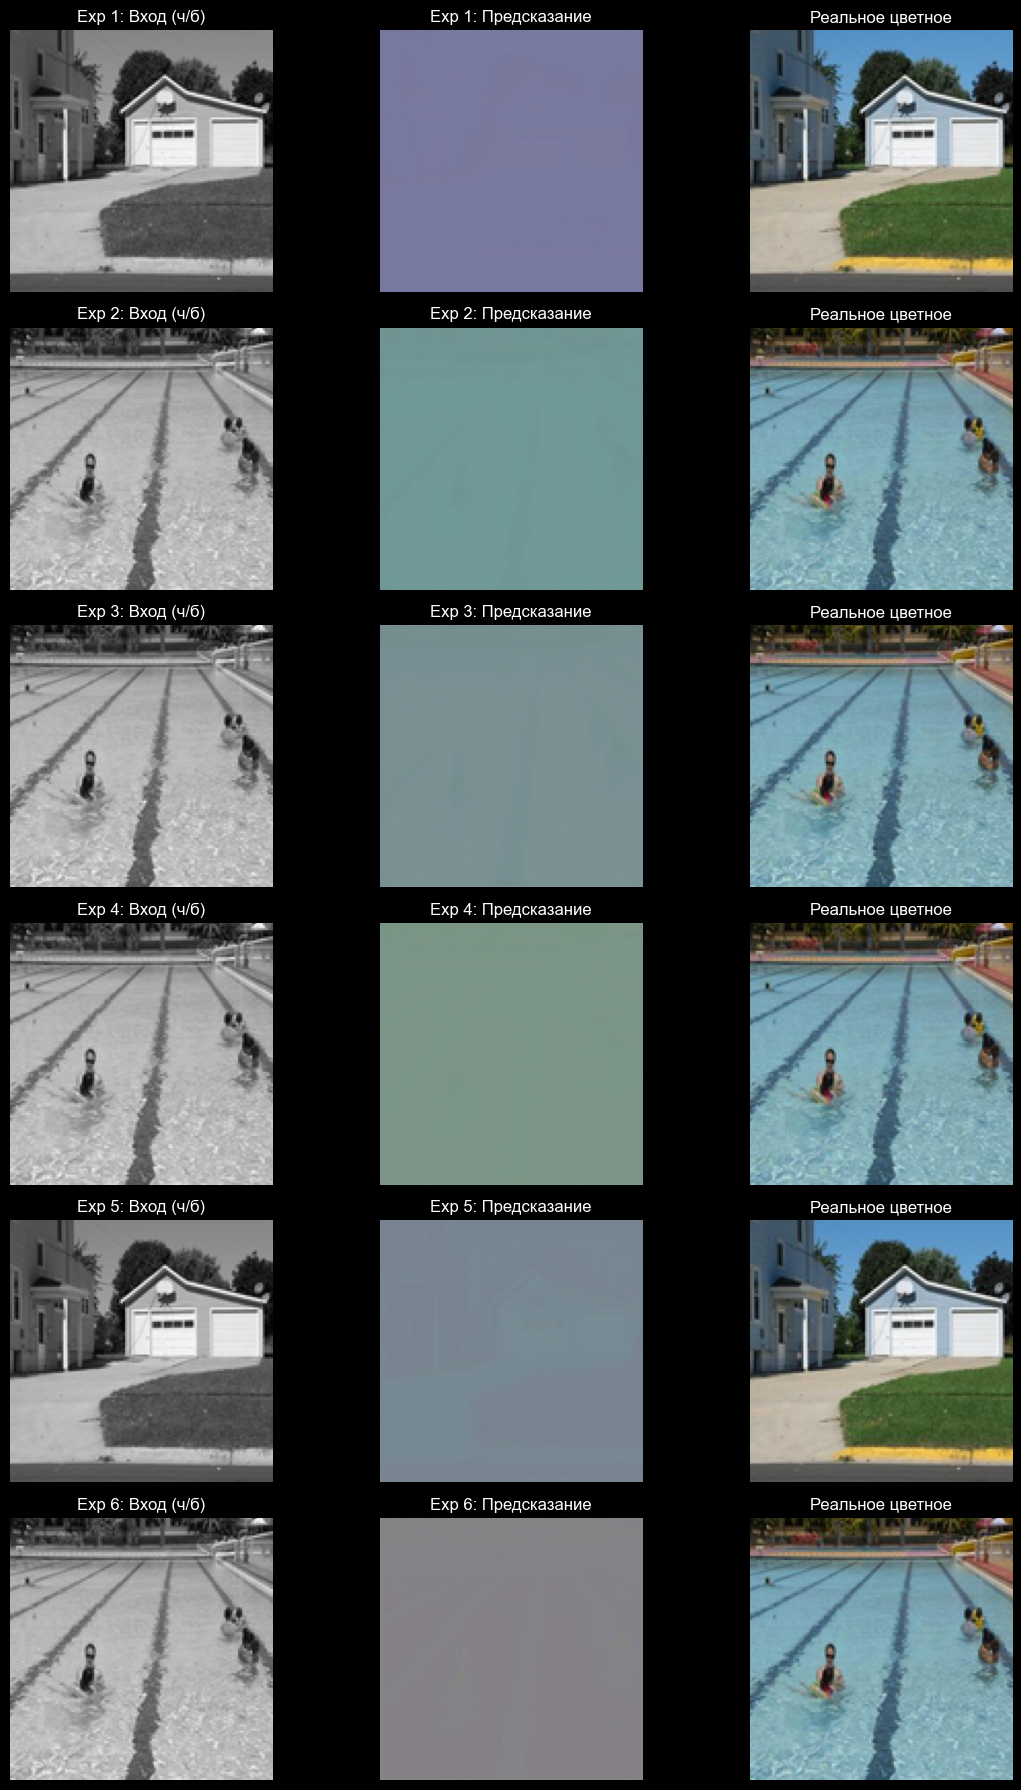

In [9]:
# Сравнение
plot_comparison(results)
show_examples(results)

In [10]:
# Находим эксперимент с самым низким финальным MSE
best_mse_idx = min(range(len(results)), key=lambda i: results[i]['losses_mse'][-1])
best_gan_idx = None

print("\n" + "="*60)
print("📊 РЕЗУЛЬТАТЫ СРАВНЕНИЯ")
print("="*60)

for idx, res in enumerate(results):
    print(f"Exp {idx+1}: MSE={res['losses_mse'][-1]:.4f}, G_loss={res['losses_G'][-1]:.4f}, D_loss={res['losses_D'][-1]:.4f}")

print(f"\n🏆 Лучший по MSE: Эксперимент {best_mse_idx+1}")
print(f"   Параметры: {results[best_mse_idx]['config']}")

# Лучший по визуальной оценке (смотрим на примеры)
print(f"\n👁️ Визуально оцените примеры выше и выберите лучший!")


📊 РЕЗУЛЬТАТЫ СРАВНЕНИЯ
Exp 1: MSE=0.2236, G_loss=2.9987, D_loss=0.6449
Exp 2: MSE=0.2158, G_loss=2.9317, D_loss=0.6395
Exp 3: MSE=0.1807, G_loss=2.1614, D_loss=0.6645
Exp 4: MSE=0.1665, G_loss=1.1710, D_loss=0.6769
Exp 5: MSE=0.2442, G_loss=1.8811, D_loss=0.6905
Exp 6: MSE=0.1021, G_loss=0.6479, D_loss=0.6805

🏆 Лучший по MSE: Эксперимент 6
   Параметры: {'lr_G': 0.0003, 'lr_D': 0.0001, 'lambda_mse': 5, 'lambda_gan': 0.2, 'd_train_freq': 3, 'num_epochs': 5}

👁️ Визуально оцените примеры выше и выберите лучший!


In [11]:
# Ручной ввод лучшего эксперимента
print("\n" + "="*60)
print("ФИНАЛЬНОЕ ОБУЧЕНИЕ")
print("="*60)

best_exp = input("Введите номер лучшего эксперимента (1-6): ")

if best_exp:
    best_config = results[int(best_exp)-1]['config'].copy()
    best_config['num_epochs'] = 30  # увеличиваем до 30 эпох
    best_config['batch_size'] = 4  # фиксируем

    print(f"\nЗапуск финального обучения с параметрами:")
    for key, value in best_config.items():
        print(f"  {key}: {value}")

    # Здесь нужно будет запустить run_experiment с num_epochs=30
    # (пока закомментировано, чтобы не запустилось случайно)

print("\n✅ Grid Search завершён!")


ФИНАЛЬНОЕ ОБУЧЕНИЕ

Запуск финального обучения с параметрами:
  lr_G: 0.0001
  lr_D: 5e-05
  lambda_mse: 5
  lambda_gan: 1
  d_train_freq: 3
  num_epochs: 30
  batch_size: 4

✅ Grid Search завершён!
